# Symmetry in Language Statistics Shapes the Geometry of Model Representations

**Paper:** Karkada, Korchinski, Nava, Wyart & Bahri (2026). arXiv: 2602.15029

This is an **exercise notebook**. Cells marked `[SKELETON]` are pre-built — read them carefully,
they contain the scaffolding and helpers you will need. Cells marked `[FILL IN]` contain a
function stub with hints; your job is to implement the body.

## The core claim

When you extract month representations from any language model and run PCA, the 12 months
arrange themselves in a circle. This is commonly treated as a mysterious emergent property of
neural networks. The paper argues it is *inevitable* — it follows directly from a symmetry in
how months co-occur in raw text, before any model is trained.

The chain of reasoning:

1. Month co-occurrence statistics exhibit **translation symmetry**: how often month $i$ and month $j$
   appear near each other depends mainly on the cyclic distance $|i - j| \pmod{12}$.
2. Translation symmetry makes the co-occurrence matrix approximately **circulant**.
3. Circulant matrices are diagonalised by the **DFT** — their eigenvectors are sines and cosines.
4. Language models learn representations that approximate the top eigenvectors of the normalised
   co-occurrence matrix.
5. The top eigenvectors of a circulant matrix are the lowest-frequency Fourier modes, which trace
   a **circle** when plotted in 2D.

We will verify each link in this chain using nothing but corpus statistics — no models trained.

---

## Structure

| Section | Topic | Mode |
|---------|-------|------|
| 0 | Setup, corpus loading, helpers | SKELETON |
| 1 | Verifying translation symmetry | FILL IN |
| 2 | From statistics to geometry | FILL IN |
| 3 | Robustness: remove direct co-occurrences | FILL IN |
| 4 | Toy illustration of the Fourier argument | FILL IN |

---
## Section 0 — Setup and Data Loading `[SKELETON]`

In [1]:
from __future__ import annotations

import re
from collections import Counter
from collections.abc import Iterator

import einops
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import scipy.sparse as sp
import torch
from datasets import load_dataset
from tqdm.notebook import tqdm

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')

plt.rcParams.update({
    'figure.figsize': (9, 7),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

Using device: mps


In [17]:
# ── Corpus loading ────────────────────────────────────────────────────────────
# WikiText-103 (~103 M tokens) is large enough for stable month statistics.
# Set MAX_DOCS to a small number (e.g. 2000) for quick iteration while developing;
# set to None to use the full corpus for final results.
MAX_DOCS: int | None = 300000

print('Loading WikiText-103...')
dataset = load_dataset('wikitext', 'wikitext-103-raw-v1', split='train')
raw_docs: list[str] = [doc for doc in dataset['text'] if doc.strip()]
if MAX_DOCS is not None:
    raw_docs = raw_docs[:MAX_DOCS]
print(f'Documents loaded: {len(raw_docs):,}')

Loading WikiText-103...
Documents loaded: 300,000


In [18]:
# ── Word lists ────────────────────────────────────────────────────────────────
MONTHS: list[str] = [
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
]
MONTH_TO_IDX: dict[str, int] = {m: i for i, m in enumerate(MONTHS)}
MONTH_ABBR: list[str] = [m[:3].capitalize() for m in MONTHS]

# Negative control for Exercise 1: 12 animals with no periodic structure
ANIMALS: list[str] = [
    'dog', 'cat', 'lion', 'tiger', 'bear', 'wolf',
    'fox', 'deer', 'rabbit', 'eagle', 'shark', 'whale',
]
ANIMAL_TO_IDX: dict[str, int] = {a: i for i, a in enumerate(ANIMALS)}
ANIMAL_ABBR: list[str] = [a[:3].capitalize() for a in ANIMALS]

# ── Tokenisation helpers ──────────────────────────────────────────────────────
def tokenize(text: str) -> list[str]:
    """Lowercase and split on non-alphabetic characters."""
    return re.findall('[a-z]+', text.lower())


def split_sentences(text: str) -> list[list[str]]:
    """Split text on sentence-ending punctuation; return tokenised sentences."""
    sentences = []
    for chunk in re.split('[.!?]', text):
        toks = tokenize(chunk)
        if toks:
            sentences.append(toks)
    return sentences


def iter_cooccurrence_pairs(
    tokens: list[str],
    window_size: int = 5,
) -> Iterator[tuple[str, str]]:
    """
    Yield every ordered pair (tokens[i], tokens[j]) where 0 < j - i <= window_size.
    Each unordered pair is yielded ONCE in each direction (a, b) and (b, a) are
    NOT both yielded — the caller decides how to symmetrise the count matrix.
    """
    n = len(tokens)
    for i in range(n):
        for j in range(i + 1, min(i + window_size + 1, n)):
            yield tokens[i], tokens[j]


def build_vocabulary(
    tokens: list[str],
    max_vocab_size: int = 20_000,
    min_count: int = 5,
) -> list[str]:
    """
    Return the top `max_vocab_size` tokens by frequency (>= min_count).
    All 12 month names are always included regardless of frequency.
    """
    counts = Counter(tokens)
    vocab = [w for w, c in counts.most_common(max_vocab_size) if c >= min_count]
    for month in MONTHS:
        if month not in vocab:
            vocab.append(month)
    return vocab


# ── Preprocess the full corpus once ──────────────────────────────────────────
# all_tokens  : flat list of tokens (for co-occurrence counting)
# all_sentences: list of tokenised sentences (for Exercise 3 filtering)
print('Tokenising corpus...')
all_tokens: list[str] = []
all_sentences: list[list[str]] = []

for doc in tqdm(raw_docs, desc='docs'):
    for sent in split_sentences(doc):
        all_sentences.append(sent)
        all_tokens.extend(sent)

print(f'Total tokens    : {len(all_tokens):,}')
print(f'Total sentences : {len(all_sentences):,}')

# Build vocabulary
print('Building vocabulary...')
VOCAB: list[str] = build_vocabulary(all_tokens, max_vocab_size=20_000)
VOCAB_TO_IDX: dict[str, int] = {w: i for i, w in enumerate(VOCAB)}
V: int = len(VOCAB)
print(f'Vocabulary size : {V:,}')
print(f'Month indices   : { {m: VOCAB_TO_IDX.get(m) for m in MONTHS} }')

Tokenising corpus...


docs:   0%|          | 0/300000 [00:00<?, ?it/s]

Total tokens    : 21,447,063
Total sentences : 1,160,202
Building vocabulary...
Vocabulary size : 20,000
Month indices   : {'january': 207, 'february': 272, 'march': 187, 'april': 193, 'may': 70, 'june': 175, 'july': 181, 'august': 165, 'september': 151, 'october': 174, 'november': 188, 'december': 211}


In [14]:
# ── Reusable plotting helpers (used in Sections 2 and 3) ─────────────────────

def plot_month_circle(
    projections: torch.Tensor,
    title: str = 'Month Representations (PCA)',
    ax: plt.Axes | None = None,
) -> None:
    """
    Plot the 12 months in 2D PCA space.

    Args:
        projections: (12, 2) tensor of 2D coordinates, one row per month
                     in the order defined by MONTHS.
    """
    xy = projections.cpu().float().numpy()
    colors = cm.hsv(np.linspace(0, 1, 13)[:12])

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(xy[:, 0], xy[:, 1], c=colors, s=180, zorder=5)
    for i, abbr in enumerate(MONTH_ABBR):
        ax.annotate(abbr, xy[i], textcoords='offset points',
                    xytext=(10, 4), fontsize=11, fontweight='bold')
    # Connect adjacent months (wrapping Dec → Jan)
    for i in range(12):
        j = (i + 1) % 12
        ax.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]],
                color='grey', alpha=0.45, linewidth=1.4)

    ax.set_title(title)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)
    if standalone:
        plt.tight_layout()
        plt.show()


def plot_eigenvalue_spectrum(
    eigenvalues: torch.Tensor,
    title: str = 'Eigenvalue Spectrum',
    ax: plt.Axes | None = None,
) -> None:
    """Stem plot of eigenvalues sorted descending."""
    vals = eigenvalues.cpu().float().numpy()
    vals = np.sort(vals)[::-1]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4))

    ax.stem(range(len(vals)), vals, basefmt=' ')
    ax.set_xlabel('Component index')
    ax.set_ylabel('Eigenvalue')
    ax.set_title(title)
    if standalone:
        plt.tight_layout()
        plt.show()

---
## Section 1 — Exercise 1: Verifying Translation Symmetry `[FILL IN]`

**Goal:** Confirm empirically that month–month co-occurrence statistics exhibit translation
symmetry — i.e., how often month $i$ and month $j$ co-occur depends primarily on the cyclic
distance $|i - j| \pmod{12}$, not on their absolute identities.

If this holds, the 12×12 co-occurrence matrix should be approximately **circulant**: each row
is a cyclic shift of the previous row.

### 1.1 — Build the 12×12 month co-occurrence matrix `[FILL IN]`

For each pair of positions $(i, j)$ in `tokens` with $0 < j - i \leq$ `window_size`,
if both `tokens[i]` and `tokens[j]` are month names, increment `C[month_i, month_j]`
**and** `C[month_j, month_i]` by 1 (co-occurrence is symmetric).

**Hint:** `iter_cooccurrence_pairs` from Section 0 yields `(tokens[i], tokens[j])` pairs
in order; use it to avoid writing the nested loop yourself.

**Note on "May":** Since we lowercase everything, `'may'` captures the modal verb as well as
the month. Keep it for now and note the effect in Discussion 1.5.

In [19]:
import itertools

def build_word_cooccurrence(
    tokens: list[str],
    word_list: list[str],
    word_to_idx: dict[str, int],
    window_size: int = 5,
) -> np.ndarray:
    """
    Build an N×N co-occurrence count matrix restricted to `word_list`.

    Args:
        tokens      : flat list of all tokens in the corpus
        word_list   : list of N target words (defines the matrix rows/cols)
        word_to_idx : mapping from each word in word_list to its row/col index
        window_size : context window half-size

    Returns:
        C : np.ndarray of shape (N, N), symmetric, C[i, j] = C[j, i]
    """
    N = len(word_list)
    C = np.zeros((N, N), dtype=np.float64)

    # ── YOUR CODE BELOW ───────────────────────────────────────────────────────
    # Iterate over co-occurrence pairs using iter_cooccurrence_pairs.
    # For each pair (w_a, w_b):
    #   - Check if BOTH w_a and w_b are in word_to_idx.
    #   - If so, increment C[word_to_idx[w_a], word_to_idx[w_b]] and
    #     C[word_to_idx[w_b], word_to_idx[w_a]] by 1.
    # (iter_cooccurrence_pairs yields each pair in one direction only,
    #  so you need to add to both directions manually.)
    for w_a, w_b in iter_cooccurrence_pairs(tokens, window_size):
        if w_a in word_to_idx and w_b in word_to_idx:
            idx_a = word_to_idx[w_a]
            idx_b = word_to_idx[w_b]
            C[idx_a, idx_b] += 1
            C[idx_b, idx_a] += 1
    return C
            
        



# Run it for months (window_size=5 is fast; try 10 and 20 later)
WINDOW_SIZE = 20
C_months = build_word_cooccurrence(all_tokens, MONTHS, MONTH_TO_IDX, window_size=WINDOW_SIZE)
print(f'C_months shape: {C_months.shape}')
print(f'Total month co-occurrences: {C_months.sum() / 2:.0f}')

C_months shape: (12, 12)
Total month co-occurrences: 44100


### 1.2 — Visualise the matrix as a heatmap `[SKELETON]`

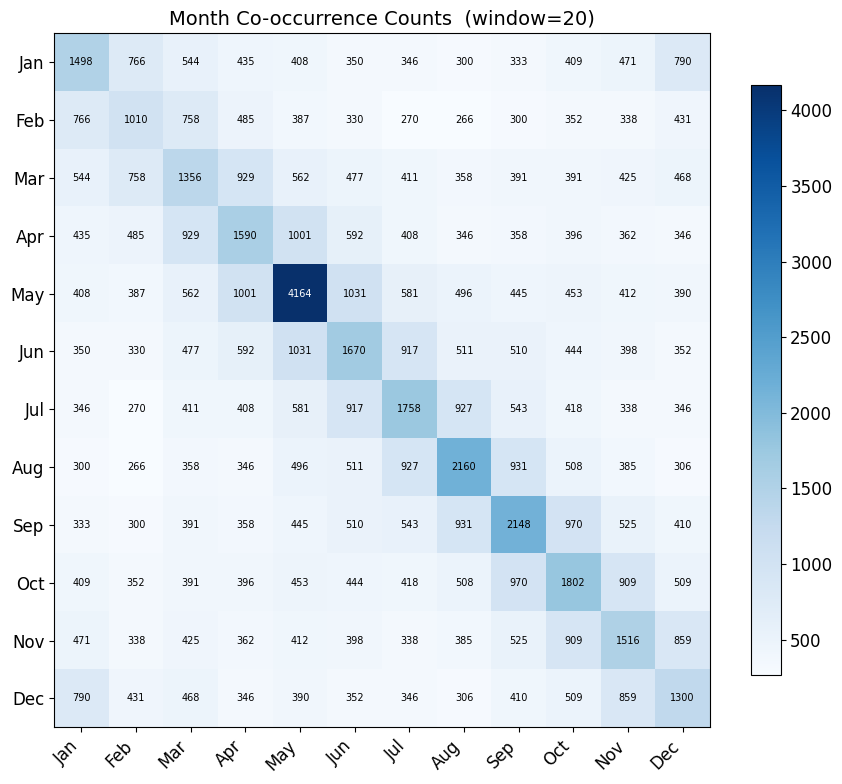

In [20]:
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(C_months, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.85)

ax.set_xticks(range(12))
ax.set_yticks(range(12))
ax.set_xticklabels(MONTH_ABBR, rotation=45, ha='right')
ax.set_yticklabels(MONTH_ABBR)

# Annotate cells
vmax = C_months.max()
for i in range(12):
    for j in range(12):
        val = C_months[i, j]
        color = 'white' if val > 0.6 * vmax else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                fontsize=7, color=color)

ax.set_title(f'Month Co-occurrence Counts  (window={WINDOW_SIZE})')
plt.tight_layout()
plt.show()

# If the matrix is approximately circulant you should see:
#  - High values near the main diagonal (adjacent months).
#  - Values falling off as distance increases.
#  - Wraparound: top-right and bottom-left corners (Dec↔Jan) should be non-zero.

### 1.3 — Quantify circulant structure `[FILL IN]`

For a perfectly circulant 12×12 matrix, entry $C(i, j)$ depends only on the
cyclic distance $d = \min(|i - j|,\, 12 - |i - j|)$ — a number from 0 to 6.

**Your tasks:**
1. Group all off-diagonal entries by their cyclic distance $d \in \{1, \ldots, 6\}$.
2. Compute the mean and standard deviation of co-occurrence counts at each $d$.
3. Compute the **variance explained by distance**: how much of the total off-diagonal
   variance is captured by knowing $d$ alone?
   $$R^2 = 1 - \frac{\text{mean within-group variance}}{\text{total variance}}$$
4. Plot mean ± 1 std as a function of $d$. A tight plot with small error bars means
   strong circulant structure.

Variance explained by cyclic distance (months): 0.987


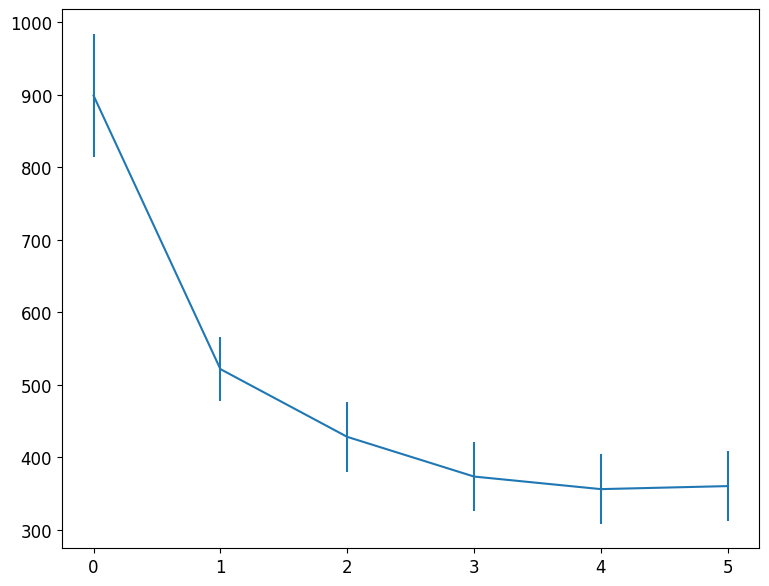

In [27]:
def quantify_circulant_structure(
    C: np.ndarray,
    word_abbr: list[str],
    label: str = '',
) -> float:
    """
    Measure how close C is to circulant. Plots mean co-occurrence vs. cyclic distance.

    Args:
        C         : (N, N) symmetric co-occurrence matrix
        word_abbr : list of N abbreviated word labels (for reporting)
        label     : title suffix for the plot

    Returns:
        r2 : variance explained by distance (float in [0, 1])
    """
    N = len(C)
    max_dist = N // 2  # for N=12, distances 1..6
    distances = list(range(max_dist))

    # ── YOUR CODE BELOW ───────────────────────────────────────────────────────
    # Step 1: Build a list `groups` where groups[d] contains all off-diagonal
    #         entries C[i, j] whose cyclic distance is d.
    #         Cyclic distance: d = min(|i - j|, N - |i - j|)
    #         Only include i != j (skip the diagonal).
    groups = [[] for _ in distances]
    for i, j in itertools.product(range(N), range(N)):
        if i != j:
            d = min(abs(i-j), N - abs(i-j))
            groups[d-1].append(C[i,j])
            

    # Step 2: For each d in 1..max_dist, compute mean and std of groups[d].
    all_entries = np.array([entry for group in groups for entry in group])
    total_var = all_entries.var()
    n_all = len(all_entries)

    means = []
    weighted_vars = []
    stds = []
    for group in groups:
        n_group = len(group)
        group = np.array(group)
        means.append(group.mean())
        stds.append(group.std())
        weighted_vars.append(group.var() * n_group / n_all)

    # Step 3: Compute R²:
    #   - total_variance = variance of ALL off-diagonal entries
    #   - within_group_variance = average of the per-group variances
    #     (weight each group by its size)
    #   - R² = 1 - within_group_variance / total_variance
    within_group_var = np.array(weighted_vars).mean()
    r2 = 1 - within_group_var / total_var

    # Step 4: Plot mean ± std vs. d.
    plt.errorbar(distances, means, yerr=stds)
    return r2



r2_months = quantify_circulant_structure(C_months, MONTH_ABBR, label='Months')
print(f'Variance explained by cyclic distance (months): {r2_months:.3f}')

### 1.4 — Negative control: animals `[FILL IN]`

Repeat the analysis above on `ANIMALS` — 12 common animal names that have no inherent
cyclic/periodic structure. The prediction is that their co-occurrence matrix will **not**
be approximately circulant: variance within each distance group will be large, and $R^2$
should be much lower than for months.

Plot the two $R^2$ values side by side for comparison.

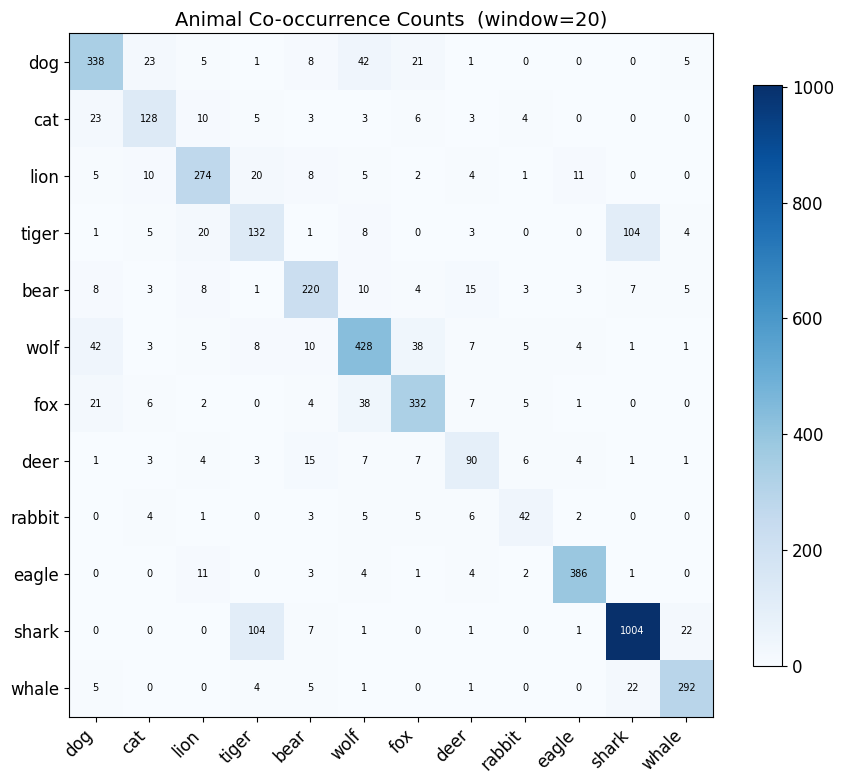

Variance explained by cyclic distance (animals): 0.854


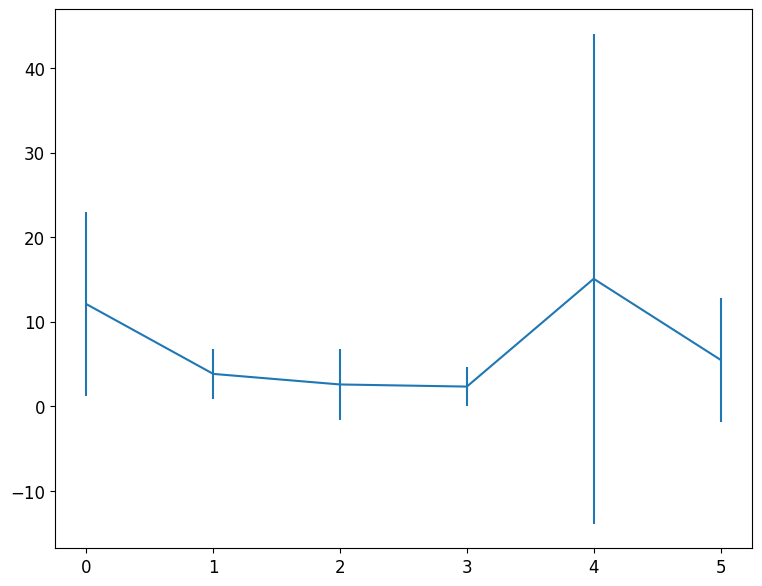

In [29]:
# ── YOUR CODE BELOW ───────────────────────────────────────────────────────────
# 1. Build C_animals using build_word_cooccurrence with ANIMALS and ANIMAL_TO_IDX.
# 2. Call quantify_circulant_structure on C_animals.
# 3. Print and compare r2_animals with r2_months.
# 4. (Optional) Plot the two heatmaps side by side so the contrast is visual.
C_animals = build_word_cooccurrence(all_tokens, ANIMALS, ANIMAL_TO_IDX, window_size=WINDOW_SIZE)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(C_animals, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.85)

ax.set_xticks(range(12))
ax.set_yticks(range(12))
ax.set_xticklabels(ANIMALS, rotation=45, ha='right')
ax.set_yticklabels(ANIMALS)

# Annotate cells
vmax = C_animals.max()
for i in range(12):
    for j in range(12):
        val = C_animals[i, j]
        color = 'white' if val > 0.6 * vmax else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                fontsize=7, color=color)

ax.set_title(f'Animal Co-occurrence Counts  (window={WINDOW_SIZE})')
plt.tight_layout()
plt.show()

r2_animals = quantify_circulant_structure(C_animals, ANIMALS, label='Animals')
print(f'Variance explained by cyclic distance (animals): {r2_animals:.3f}')

# If the matrix is approximately circulant you should see:
#  - High values near the main diagonal (adjacent months).
#  - Values falling off as distance increases.
#  - Wraparound: top-right and bottom-left corners (Dec↔Jan) should be non-zero.


### 1.5 — Discussion `[SKELETON]`

Answer in the cell below (convert it to Markdown or write in comments):

1. How close to circulant is the month matrix? What does the $R^2$ value tell you?
2. Which month pairs deviate most from the circulant prediction? Can you explain why?
   (Hint: think about holidays, academic calendars, seasonal patterns.)
3. How does 'May' behave compared to the other months? Is its row/column noisier?
4. Try `window_size = 2, 10, 20`. How does the circulant structure change?
   What does this suggest about whether the symmetry is syntactic or semantic?

In [ ]:
# Your answers here

---
## Section 2 — Exercise 2: From Statistics to Geometry `[FILL IN]`

**Goal:** Show that the translation symmetry in co-occurrence statistics produces a circular
geometry in PCA space — *without training any model*.

### Key quantity: the normalised co-occurrence matrix $M^*$

Raw co-occurrence is dominated by frequent words ('the', 'of', ...). To control for this,
we divide out the baseline expectation under statistical independence:

$$M^*(i, j) = \frac{P(i, j)}{P(i)\, P(j)} = \frac{C(i, j) \cdot N}{\text{count}(i) \cdot \text{count}(j)}$$

where $N$ is the total number of co-occurrence pairs and $\text{count}(i)$ is the unigram
frequency of word $i$. Values above 1 mean the pair co-occurs more than chance; below 1 means
less. (The log of $M^*$ is the pointwise mutual information, PMI.)

We will compute the 12 rows of $M^*$ corresponding to the months and run PCA on them.

### 2.1 — Build the full sparse co-occurrence matrix `[FILL IN]`

This is the expensive step. We need co-occurrence counts for ALL vocabulary pairs, not just
months, because the M* row for 'january' is a V-dimensional vector over the whole vocabulary.

**Implementation notes:**
- Use `scipy.sparse.dok_matrix` (dictionary-of-keys) for building, then convert to CSR.
- Each pair $(w_a, w_b)$ from `iter_cooccurrence_pairs` should increment both
  `C[idx_a, idx_b]` and `C[idx_b, idx_a]`.
- Skip pairs where either word is not in `VOCAB_TO_IDX`.
- Also accumulate unigram counts (you can count tokens in a single pass over `all_tokens`).

**Expected output:** `C` is a `(V, V)` sparse CSR matrix; `unigram_counts` is a `(V,)` array.

In [ ]:
def build_full_cooccurrence(
    tokens: list[str],
    vocab_to_idx: dict[str, int],
    window_size: int = 5,
) -> tuple[sp.csr_matrix, np.ndarray]:
    """
    Build the full V×V sparse co-occurrence matrix and unigram counts.

    Args:
        tokens       : flat list of corpus tokens
        vocab_to_idx : word → row/col index mapping
        window_size  : context window size

    Returns:
        C              : scipy.sparse.csr_matrix, shape (V, V), symmetric
        unigram_counts : np.ndarray, shape (V,), raw token frequencies
    """
    V = len(vocab_to_idx)
    unigram_counts = np.zeros(V, dtype=np.float64)

    # ── YOUR CODE BELOW ───────────────────────────────────────────────────────
    # Step 1: Compute unigram_counts.
    #   For each token in `tokens`, if it's in vocab_to_idx,
    #   increment unigram_counts[vocab_to_idx[token]] by 1.

    # Step 2: Build the sparse co-occurrence matrix.
    #   Use sp.dok_matrix((V, V), dtype=np.float64) as the accumulator.
    #   Iterate over iter_cooccurrence_pairs(tokens, window_size).
    #   For each pair (w_a, w_b) where both are in vocab_to_idx:
    #     dok[idx_a, idx_b] += 1
    #     dok[idx_b, idx_a] += 1
    #   (wrap the loop in tqdm for progress tracking)

    # Step 3: Convert dok to CSR: C = dok.tocsr()
    # Step 4: Return C, unigram_counts

    raise NotImplementedError


print('Building full co-occurrence matrix (this may take a few minutes)...')
C_full, unigram_counts = build_full_cooccurrence(all_tokens, VOCAB_TO_IDX, window_size=WINDOW_SIZE)
print(f'C_full shape   : {C_full.shape}')
print(f'Non-zero entries: {C_full.nnz:,}')
print(f'Total co-occurrence pairs: {C_full.sum() / 2:.0f}')

### 2.2 — Compute $M^*$ for the 12 months `[FILL IN]`

We only need the 12 rows of $M^*$ corresponding to month names. Each row is a $V$-dimensional
vector representing one month's normalised co-occurrence profile with every vocabulary word.

$$M^*(\text{month}_i,\, j) = \frac{C(\text{month}_i,\, j) \cdot N}{\text{count}(\text{month}_i) \cdot \text{count}(j)}$$

where $N = \sum_{i,j} C(i,j)$ is the total co-occurrence count.

**Watch out for:** divisions by zero when a vocabulary word has zero unigram count (shouldn't
happen after vocabulary filtering, but guard against it anyway).

**Return** a `torch.Tensor` of shape `(12, V)` on `DEVICE`.

In [ ]:
def compute_mstar_months(
    C: sp.csr_matrix,
    unigram_counts: np.ndarray,
    vocab_to_idx: dict[str, int],
) -> torch.Tensor:
    """
    Compute the 12 rows of M* corresponding to MONTHS.

    Args:
        C              : (V, V) sparse co-occurrence matrix
        unigram_counts : (V,) unigram frequencies
        vocab_to_idx   : word → index mapping

    Returns:
        mstar : torch.Tensor of shape (12, V) on DEVICE
    """
    V = len(vocab_to_idx)

    # ── YOUR CODE BELOW ───────────────────────────────────────────────────────
    # Step 1: Compute N = C.sum() (total co-occurrence count, a scalar).

    # Step 2: For each month in MONTHS:
    #   - Find its index in vocab_to_idx.
    #   - Extract the corresponding row from C as a dense numpy array:
    #     row = np.asarray(C[month_idx, :].todense()).flatten()
    #   - Compute M*(month, j) = row[j] * N / (unigram_counts[month_idx] * unigram_counts[j])
    #     Use np.divide with `where=unigram_counts > 0` to avoid division by zero,
    #     setting the result to 0 where unigram_counts is 0.

    # Step 3: Stack the 12 rows into a (12, V) array and convert to a torch.Tensor on DEVICE.

    raise NotImplementedError


mstar_months = compute_mstar_months(C_full, unigram_counts, VOCAB_TO_IDX)
print(f'mstar_months shape : {mstar_months.shape}')
print(f'mstar_months dtype : {mstar_months.dtype}')
print(f'mstar_months device: {mstar_months.device}')

### 2.3 — PCA on the month vectors `[FILL IN]`

We have 12 vectors in $V$-dimensional space. PCA finds the directions of maximum variance.
With only 12 data points the problem is effectively at most 11-dimensional — so we can work
with the 12×12 covariance matrix rather than the V×V one.

**Steps:**
1. Mean-centre: subtract the mean across the 12 month vectors.
2. Use `torch.linalg.svd` on the centred (12, V) matrix `X`:
   `U, S, Vt = torch.linalg.svd(X, full_matrices=False)`
   - `U` is (12, 12) — the projections live here.
   - `S` are the singular values; eigenvalues of `X @ X.T` are `S²`.
   - The 2D projections of each month are the first 2 columns of `U * S`.
3. Return `projections` (12, n_components) and `eigenvalues` (12,).

**einops note:** Use `einops.reduce` or `einops.rearrange` if it makes your code clearer.

In [ ]:
def pca_on_month_vectors(
    mstar_months: torch.Tensor,
    n_components: int = 2,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Run PCA on the 12 month M* vectors.

    Args:
        mstar_months : (12, V) tensor on DEVICE
        n_components : number of principal components to return

    Returns:
        projections  : (12, n_components) tensor — 2D (or nD) coordinates
        eigenvalues  : (12,) tensor — eigenvalues sorted descending
    """
    # ── YOUR CODE BELOW ───────────────────────────────────────────────────────
    # Step 1: Mean-centre.
    #   mean = einops.reduce(mstar_months, 'months vocab -> 1 vocab', 'mean')
    #   X = mstar_months - mean

    # Step 2: SVD.
    #   U, S, Vt = torch.linalg.svd(X, full_matrices=False)

    # Step 3: Projections = U * S  (broadcast: U is (12,12), S is (12,))
    #   projections = (U * S)[:, :n_components]

    # Step 4: Eigenvalues = S**2  (sorted descending, which SVD already gives us)

    raise NotImplementedError


projections_2d, eigenvalues = pca_on_month_vectors(mstar_months, n_components=2)
print(f'projections shape: {projections_2d.shape}')
print(f'top 4 eigenvalues: {eigenvalues[:4].tolist()}')

### 2.4 — Plot the circle `[SKELETON]`

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_month_circle(
    projections_2d,
    title=f'Month M* Vectors — PCA (window={WINDOW_SIZE})',
    ax=axes[0],
)
plot_eigenvalue_spectrum(
    eigenvalues,
    title='PCA Eigenvalue Spectrum',
    ax=axes[1],
)
plt.tight_layout()
plt.show()

# What to look for:
#  - Left: the 12 months should lie approximately on a circle, in calendar order.
#  - Right: the eigenvalue spectrum should have a clear gap after index 1 (the k=1 Fourier mode
#    dominates), with the next pair (k=2) smaller, and so on.

### 2.5 — The Fourier comparison `[FILL IN]`

This is the central theoretical prediction: because the month–month submatrix of $M^*$ is
approximately circulant, its eigenvalues can be predicted from the **DFT of its first row**.

**Steps:**
1. Extract the 12×12 submatrix `M_sub` of `mstar_months` — the month–month block.
   (`M_sub[i, j]` = M*(month_i, month_j) )
2. Compute the **circulant approximation**: for each cyclic distance $d \in \{0,\ldots,11\}$,
   average all entries where $(j - i) \bmod 12 = d$. This gives a 12-element vector `c` —
   the first row of the best circulant fit to `M_sub`.
3. Compute `torch.fft.rfft(c)` (or `torch.fft.fft`). The magnitudes of the DFT coefficients
   are the **predicted eigenvalues** of the circulant matrix.
4. Plot the DFT-predicted eigenvalues against the actual PCA eigenvalues from 2.3.
5. Also plot the **power spectrum** of `c` (|FFT|² vs. frequency $k$). The prediction is that
   power is concentrated at low frequencies, with $k=1$ dominant.

In [ ]:
def fourier_comparison(
    mstar_months: torch.Tensor,
    pca_eigenvalues: torch.Tensor,
    vocab_to_idx: dict[str, int],
) -> None:
    """
    Compare DFT-predicted eigenvalues to actual PCA eigenvalues.

    Args:
        mstar_months   : (12, V) M* tensor
        pca_eigenvalues: (12,) sorted-descending PCA eigenvalues
        vocab_to_idx   : word → index mapping
    """
    # ── YOUR CODE BELOW ───────────────────────────────────────────────────────
    # Step 1: Extract M_sub (12, 12).
    #   month_indices = [vocab_to_idx[m] for m in MONTHS]
    #   M_sub = mstar_months[:, month_indices]   # (12, 12)

    # Step 2: Circulant approximation.
    #   For d in range(12):
    #     collect all M_sub[i, j] where (j - i) % 12 == d
    #     c[d] = mean of those entries
    #   Result: c is a (12,) tensor

    # Step 3: DFT.
    #   fft_coeffs = torch.fft.fft(c.float())
    #   predicted_eigenvalues = fft_coeffs.real  (they should be real for a symmetric circulant)
    #   power_spectrum = fft_coeffs.abs() ** 2

    # Step 4: Plots.
    #   fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    #   axes[0]: bar chart comparing predicted_eigenvalues (sorted) vs pca_eigenvalues
    #   axes[1]: stem plot of power_spectrum vs frequency k (0..11)
    #   Label the k=1 bar/point prominently.

    raise NotImplementedError


fourier_comparison(mstar_months, eigenvalues, VOCAB_TO_IDX)

### 2.6 — Higher harmonics `[FILL IN]`

The circle is the $k=1$ Fourier mode. But the $k=2, 3, \ldots$ modes are also present and
correspond to higher principal components.

**Tasks:**
1. Run PCA with `n_components=8` to get PC1–PC8.
2. Plot PC1 vs. PC2, PC3 vs. PC4, PC5 vs. PC6 side by side. Each pair should trace a circle
   at an increasing frequency: PC1/2 are one full loop, PC3/4 are a double loop, etc.
3. Compute the **reconstruction error** as a function of embedding dimension $d$:
   $$\text{error}(d) = \|X - X_d\|_F^2 / \|X\|_F^2$$
   where $X$ is the centred (12, V) matrix and $X_d$ is its rank-$d$ reconstruction.
   With SVD: $X_d = U_d \cdot \text{diag}(S_d) \cdot V_d^T$.
   Plot error vs. $d$ for $d = 1, 2, \ldots, 11$.

**einops hint:** `U_d = U[:, :d]`, `S_d = S[:d]`. Reconstruction:
`X_d = einops.einsum(U_d * S_d, Vt[:d, :], 'months k, k vocab -> months vocab')`

In [ ]:
def analyze_higher_harmonics(mstar_months: torch.Tensor) -> None:
    """
    Visualise higher-order Fourier harmonics in the PCA decomposition.

    Args:
        mstar_months : (12, V) M* tensor
    """
    # ── YOUR CODE BELOW ───────────────────────────────────────────────────────
    # Step 1: Mean-centre and run full SVD.
    #   X = mstar_months - einops.reduce(mstar_months, 'm v -> 1 v', 'mean')
    #   U, S, Vt = torch.linalg.svd(X, full_matrices=False)  # U: (12,12), S: (12,), Vt: (12,V)

    # Step 2: Plot PC pairs.
    #   projections_8d = (U * S)[:, :8]  # (12, 8)
    #   fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    #   For each pair (0,1), (2,3), (4,5): call plot_month_circle on the two columns.

    # Step 3: Reconstruction error.
    #   X_norm_sq = (X ** 2).sum().item()
    #   For d in range(1, 12):
    #     X_d = einops.einsum(U[:, :d] * S[:d], Vt[:d, :], 'm k, k v -> m v')
    #     error = ((X - X_d) ** 2).sum().item() / X_norm_sq
    #   Plot error vs d as a line plot.

    raise NotImplementedError


analyze_higher_harmonics(mstar_months)

### 2.7 — Discussion `[SKELETON]`

Answer in the cell below:

1. How well do the DFT-predicted eigenvalues match the PCA eigenvalues? Where do they agree
   best? Where do they diverge, and why?
2. The power spectrum of `c` should show most energy at $k=1$. Explain in one sentence *why*
   a smooth, monotonically-decaying co-occurrence function has its DFT dominated by low frequencies.
3. PC3/4 should trace a double loop. Label which months appear where. Does the ordering
   still make calendar sense?
4. From the reconstruction-error plot: how many dimensions are 'needed' to represent months?
   What does this tell you about how many SAE features you'd expect to encode month information?

In [ ]:
# Your answers here

---
## Section 3 — Exercise 3: Robustness to Perturbation `[FILL IN]`

**Goal:** Show that the circular geometry *survives even when you remove all sentences where
two or more months co-occur directly.*

**Why this matters:** If the circle were purely caused by months appearing next to each other
in dates like 'January to March', removing those sentences would destroy it. But the prediction
is that each month's *indirect* profile — its relationships to non-month words like 'snow',
'summer', 'valentine' — still carries the translation symmetry. Removing direct co-occurrences
attenuates but does not destroy the circular structure.

### 3.1 — Filter the corpus `[FILL IN]`

From `all_sentences`, keep only sentences that contain **at most one** month name.
Count and report:
- How many sentences were removed.
- What fraction of the total this represents.
- Whether any months appear more frequently in filtered-out sentences (this would suggest
  some months are especially discussed together).

In [ ]:
def filter_sentences_by_month_count(
    sentences: list[list[str]],
    max_months: int = 1,
) -> tuple[list[list[str]], list[list[str]]]:
    """
    Split sentences into kept and removed groups.

    Args:
        sentences  : list of tokenised sentences
        max_months : keep sentences with at most this many distinct month mentions

    Returns:
        kept   : sentences with <= max_months month mentions
        removed: sentences with > max_months month mentions
    """
    # ── YOUR CODE BELOW ───────────────────────────────────────────────────────
    # For each sentence, count how many of its tokens are in MONTH_TO_IDX.
    # Note: a sentence like 'January, January, February' has 3 month tokens
    # but only 2 distinct months — decide whether you filter by total count
    # or distinct months (both are reasonable; note your choice).

    raise NotImplementedError


kept_sentences, removed_sentences = filter_sentences_by_month_count(all_sentences, max_months=1)
print(f'Kept   : {len(kept_sentences):,} sentences ({100*len(kept_sentences)/len(all_sentences):.1f}%)')
print(f'Removed: {len(removed_sentences):,} sentences ({100*len(removed_sentences)/len(all_sentences):.1f}%)')

# Flatten kept sentences into a token list for downstream processing
filtered_tokens: list[str] = [tok for sent in kept_sentences for tok in sent]

### 3.2 — Rebuild M* from the filtered corpus `[FILL IN]`

Reuse `build_full_cooccurrence` and `compute_mstar_months` from Section 2 on `filtered_tokens`.
Verify that the 12×12 month–month submatrix of `mstar_filtered` is approximately zero on the
off-diagonal (the direct signal has been removed).

In [ ]:
# ── YOUR CODE BELOW ───────────────────────────────────────────────────────────
# 1. Build C_filtered and unigram_filtered from filtered_tokens (same window size).
# 2. Compute mstar_filtered using compute_mstar_months.
# 3. Extract the 12×12 month–month submatrix and print its off-diagonal maximum
#    to confirm that direct month co-occurrences are near zero.

raise NotImplementedError

### 3.3 — PCA, circle plot, and eigenvalue comparison `[FILL IN]`

Run PCA on `mstar_filtered` and produce the following:

1. **Side-by-side circle plots:** original (from 2.3) vs. filtered. Do both show a circle?
   Is the filtered version noisier or rotated?
2. **Eigenvalue comparison:** plot both eigenvalue spectra overlaid. The filtered spectra
   should have smaller absolute values (less signal) but the same relative ordering
   ($k=1$ still dominates).

In [ ]:
# ── YOUR CODE BELOW ───────────────────────────────────────────────────────────
# 1. proj_filtered, evals_filtered = pca_on_month_vectors(mstar_filtered, n_components=2)

# 2. Side-by-side circle plots:
#    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
#    plot_month_circle(projections_2d, title='Original', ax=axes[0])
#    plot_month_circle(proj_filtered, title='Filtered (no direct co-occ)', ax=axes[1])

# 3. Eigenvalue comparison:
#    Plot both spectra on the same axes.
#    Normalise by each spectrum's maximum so they are on the same scale.
#    Label the k=1 frequency on the x-axis.

raise NotImplementedError

### 3.4 — Discussion `[SKELETON]`

Answer in the cell below:

1. Does the circle survive? Is it as clean as the original? Describe any differences.
2. The circle surviving means the translation symmetry is carried by *indirect* relationships —
   each month's co-occurrence profile with non-month words. Can you identify specific vocabulary
   words that might be responsible? (Hint: look at which vocabulary dimensions contribute
   most to the top PCA direction for a few months.)
3. What does this tell us about the nature of the circular geometry in LLM representations?
   Is it driven by explicit temporal co-occurrence, or something deeper?

In [ ]:
# Your answers here

---
## Section 4 — Toy Illustration: The Fourier Argument

This section is a **self-contained mathematical illustration**, independent of the corpus.
We work with a hand-crafted circulant matrix and prove to ourselves, step by step, why
circulant matrices produce circles in PCA.

### Mathematical background

An $N \times N$ circulant matrix $C$ is defined by a single vector $c = (c_0, \ldots, c_{N-1})$:
$$C(i, j) = c_{(j - i) \bmod N}$$

**Key property:** $C$ commutes with the cyclic permutation matrix $P$. Any matrix that commutes
with $P$ is diagonalised by the DFT. The eigenvectors are:
$$v_k(n) = \frac{1}{\sqrt{N}} e^{2\pi i k n / N}, \quad k = 0, 1, \ldots, N-1$$

For real, symmetric $C$, these complex eigenvectors pair up into real cosine/sine pairs:
$$v_k^\cos(n) = \cos\!\left(\frac{2\pi k n}{N}\right), \quad
v_k^\sin(n) = \sin\!\left(\frac{2\pi k n}{N}\right)$$

The eigenvalue for frequency $k$ is the $k$-th DFT coefficient of $c$:
$$\lambda_k = \text{DFT}(c)[k]$$

For $N = 12$, the $k=1$ mode evaluates at month index $n$ as:
$$(\cos(2\pi n/12),\ \sin(2\pi n/12))$$
which is exactly 12 equally-spaced points on a unit circle. **That is the origin of the circle.**

In [ ]:
# ── 4.1 Construct a synthetic circulant matrix [SKELETON] ─────────────────────
# First row: high for nearby months, falling off with cyclic distance.
# Distance-0 is the diagonal (self-cooccurrence); distances 1..6 fall off smoothly.
c_first_row = torch.tensor(
    [10.0, 8.0, 5.0, 2.5, 1.0, 0.5, 0.2, 0.5, 1.0, 2.5, 5.0, 8.0],
    device=DEVICE,
)  # shape (12,); note c[7..11] = c[5..1] for symmetry

N = 12

# Build the full 12x12 circulant matrix from the first row
# C_circ[i, j] = c_first_row[(j - i) % 12]
indices = torch.arange(N, device=DEVICE)
# Use einops to construct the (j - i) % 12 index matrix
i_idx = einops.repeat(indices, 'i -> i j', j=N)
j_idx = einops.repeat(indices, 'j -> i j', i=N)
dist_matrix = (j_idx - i_idx) % N           # (12, 12), values in {0,...,11}
C_circ = c_first_row[dist_matrix]           # (12, 12)

print(f'C_circ shape  : {C_circ.shape}')
print(f'Is symmetric  : {torch.allclose(C_circ, C_circ.T)}')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(C_circ.cpu().numpy(), cmap='Blues')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(12))
ax.set_yticks(range(12))
ax.set_xticklabels(MONTH_ABBR, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(MONTH_ABBR, fontsize=8)
ax.set_title('Synthetic Circulant Matrix')
plt.tight_layout()
plt.show()

### 4.2 — Diagonalise two ways `[FILL IN]`

Show that numpy eigendecomposition and the DFT give the same eigenvalues:

1. **Method 1:** `torch.linalg.eigh(C_circ)` — returns eigenvalues and eigenvectors.
2. **Method 2:** `torch.fft.fft(c_first_row)` — the DFT coefficients are the eigenvalues.

Sort both sets of eigenvalues and verify they match (up to floating point). Also
verify that the eigenvectors from Method 1 are sinusoidal (plot a few of them).

In [ ]:
# ── YOUR CODE BELOW ───────────────────────────────────────────────────────────
# Method 1: torch.linalg.eigh(C_circ)
#   evals_eigh, evecs_eigh = ...

# Method 2: torch.fft.fft(c_first_row)
#   fft_coeffs = ...
#   evals_fft  = fft_coeffs.real  (for a symmetric circulant, eigenvalues are real)

# Compare: sort both and print; assert torch.allclose(..., atol=1e-4)

raise NotImplementedError

### 4.3 — Visualise the eigenvectors `[FILL IN]`

Plot each eigenvector from Method 1 as a function of month index 0–11.
Label each with its DFT frequency $k$.
You should see:
- $k=0$: a constant vector.
- $k=1$: one full oscillation (sine or cosine).
- $k=2$: two full oscillations.
- ...
- $k=6$: alternating $+1, -1$ (Nyquist frequency).

Overlay the theoretical prediction $\cos(2\pi k n / 12)$ for each $k$ to confirm the match.

In [ ]:
# ── YOUR CODE BELOW ───────────────────────────────────────────────────────────
# fig, axes = plt.subplots(2, 4, figsize=(16, 7))  # 7 unique frequencies (k=0..6)
# For each k in 0..6:
#   - Find the eigenvector from eigh that corresponds to frequency k.
#     (Sort eigh eigenvalues and match to DFT eigenvalues to identify which is which.)
#   - Plot the eigenvector values at month indices 0..11.
#   - Overlay cos(2*pi*k*n/12) scaled to match amplitude.
#   - Title: f'k={k}  λ={eigenvalue:.2f}'

raise NotImplementedError

### 4.4 — How $k=1$ gives a circle `[FILL IN]`

The $k=1$ Fourier mode has two components: $\cos(2\pi n / 12)$ and $\sin(2\pi n / 12)$
for $n = 0, 1, \ldots, 11$.

Plot the 12 points $(\cos(2\pi n/12),\ \sin(2\pi n/12))$ for $n = 0, \ldots, 11$.
Label each point with its month abbreviation. Connect adjacent months.

This is the theoretical prediction for the PCA circle — now compare it visually to
the empirical result from Section 2.

In [ ]:
# ── YOUR CODE BELOW ───────────────────────────────────────────────────────────
n = torch.arange(12, device=DEVICE, dtype=torch.float32)

# cos_vals = torch.cos(2 * torch.pi * n / 12)
# sin_vals = torch.sin(2 * torch.pi * n / 12)
# predicted_circle = torch.stack([cos_vals, sin_vals], dim=1)  # (12, 2)

# Use plot_month_circle(predicted_circle, title='Theoretical k=1 Circle')

raise NotImplementedError

### 4.5 — Adding higher harmonics `[FILL IN]`

Start with the clean $k=1$ circle and progressively add the $k=2, 3, \ldots$ harmonics.
Each harmonic adds a sinusoidal 'ripple' to the shape.

**Steps:**
1. Compute the full spectral decomposition of `C_circ` using `torch.linalg.eigh`.
2. For a rank-$d$ approximation (keeping the top $d$ eigenvalues):
   - Compute the approximate matrix $C_d = \sum_{k=1}^{d} \lambda_k v_k v_k^T$.
   - Run PCA on the rows of $C_d$ (treating each row as a 12-dimensional vector).
   - Plot the resulting 2D projection.
3. Show approximations for $d = 2, 4, 6$ (i.e., 1, 2, 3 Fourier pairs) side by side.

You should see the circle progressively deformed as higher harmonics are added.

In [ ]:
# ── YOUR CODE BELOW ───────────────────────────────────────────────────────────
# evals_eigh, evecs_eigh = torch.linalg.eigh(C_circ)   # (already computed in 4.2)
# Sort descending for clarity.
#
# For d in [2, 4, 6]:
#   Select top-d eigenvalues/vectors.
#   C_d = einops.einsum(evecs * evals, evecs, 'n k, m k -> n m')
#   Run pca_on_month_vectors(C_d.unsqueeze(0).expand(12, -1)) ← or adapt for 12x12 input.
#   plot_month_circle(proj, title=f'd={d} components', ax=...)

raise NotImplementedError

### 4.6 — Robustness to noise `[FILL IN]`

How much random noise can you add to `C_circ` before the circular structure in PCA breaks?

**Experiment:**
1. Add Gaussian noise: `C_noisy = C_circ + sigma * torch.randn_like(C_circ)`.
   Symmetrize: `C_noisy = (C_noisy + C_noisy.T) / 2`.
2. Run PCA on rows of `C_noisy` (treating them as 12-dim vectors).
3. Measure how circular the result is using the **residual from a fitted circle**:
   fit the best-fit circle to the 12 PCA points and compute the mean squared residual.
4. Plot the residual vs. `sigma` for a range of noise levels (e.g. `sigma = 0, 0.5, 1, 2, 4, 8`).
5. Show example PCA plots at a few noise levels to illustrate the transition.

In [ ]:
def fit_circle_residual(points: torch.Tensor) -> float:
    """
    Fit a circle to `points` and return the mean squared residual.

    Args:
        points: (N, 2) tensor of 2D coordinates

    Returns:
        residual: mean squared distance from the fitted circle

    Hint: The algebraic circle fit recasts circle-fitting as a linear least-squares problem.
    For a circle (x - cx)² + (y - cy)² = r², expanding gives:
      x² + y² = 2*cx*x + 2*cy*y + (r² - cx² - cy²)
    So: [2x, 2y, 1] @ [cx, cy, r²-cx²-cy²]ᵀ = x² + y²
    Solve for [cx, cy, c] with torch.linalg.lstsq, then recover r.
    Residual = mean((distance_from_centre - r)²)
    """
    # ── YOUR CODE BELOW ─────────────────────────────────────────────────────
    raise NotImplementedError


# ── Noise sweep ───────────────────────────────────────────────────────────────
# sigmas = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]
# For each sigma:
#   C_noisy = C_circ + sigma * torch.randn_like(C_circ)
#   C_noisy = (C_noisy + C_noisy.T) / 2
#   proj, _ = pca_on_month_vectors(C_noisy, n_components=2)   # treat rows as 12-dim vectors
#   residual = fit_circle_residual(proj)
# Plot residual vs sigma.
# Show PCA circle plots at sigma = 0, 2, 8.

raise NotImplementedError